### Read CSV

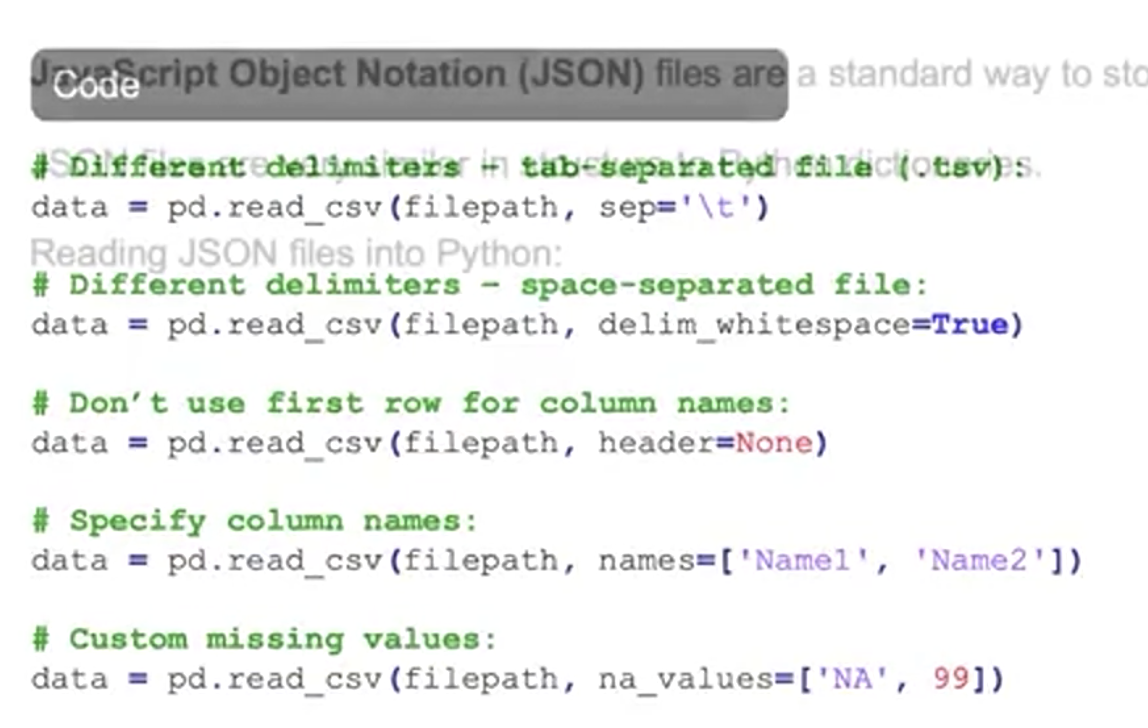

---

### Reading SQL Data


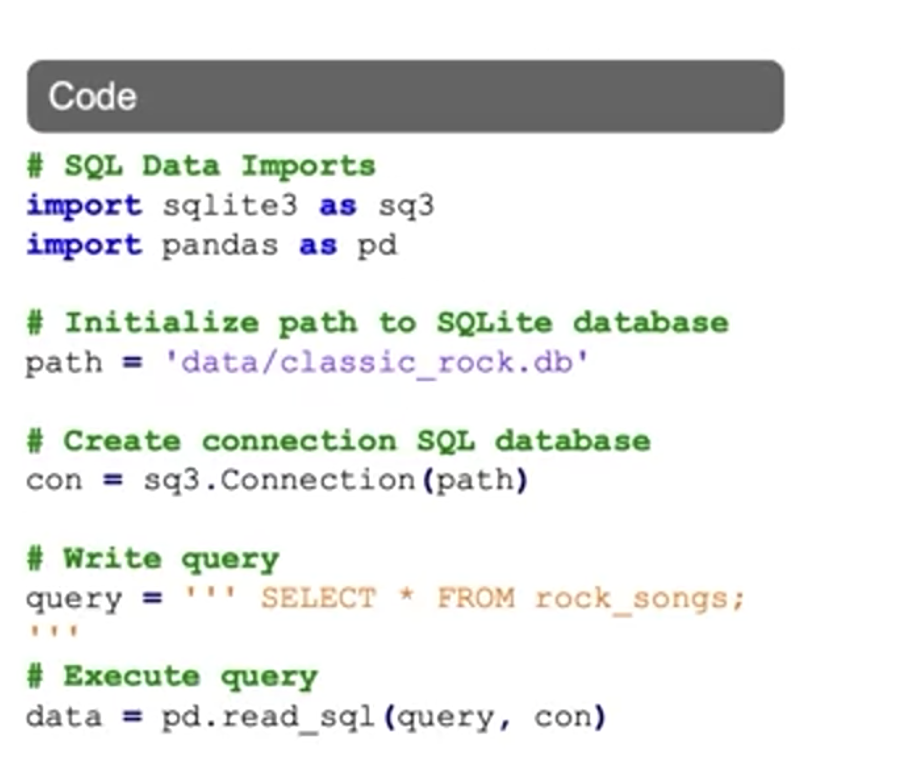

In [3]:
import sqlite3 as sq3
import pandas as pd

# Đọc file CSV
df = pd.read_csv('Automobile_data.csv')

# Loại bỏ các cột chỉ mục thừa (Unnamed) nếu có để data sạch nhất
unnamed_cols = [c for c in df.columns if 'Unnamed' in c]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Kết nối (hoặc tự tạo mới) file database SQLite: Automobile_data.db
con = sq3.connect('Automobile_data.db')

# Ghi dữ liệu vào bảng có tên là 'automobile'
df.to_sql('automobile', con, if_exists='replace', index=False)

# Đóng kết nối sau khi ghi xong
con.close()
print("-> Đã chuyển đổi thành công sang file 'Automobile_data.db'!")

-> Đã chuyển đổi thành công sang file 'Automobile_data.db'!


In [ ]:
import sqlite3 as sq3
import pandas as pd 

path = 'Automobile_data.db' #path to the database

con = sq3.Connection(path) #connect to the databas

query = ''' SELECT * FROM automobile;
'''
#if i want to select specific columns in path database, i should use the SELECT "columns" FROM database_name;
#while SELECT * is select all the columns in the database
data = pd.read_sql (query, con)
#allow pandas to read the sql path file
print(data)

    index      company   body-style  wheel-base  length engine-type  \
0       0  alfa-romero  convertible        88.6   168.8        dohc   
1       1  alfa-romero  convertible        88.6   168.8        dohc   
2       2  alfa-romero    hatchback        94.5   171.2        ohcv   
3       3         audi        sedan        99.8   176.6         ohc   
4       4         audi        sedan        99.4   176.6         ohc   
..    ...          ...          ...         ...     ...         ...   
56     81   volkswagen        sedan        97.3   171.7         ohc   
57     82   volkswagen        sedan        97.3   171.7         ohc   
58     86   volkswagen        sedan        97.3   171.7         ohc   
59     87        volvo        sedan       104.3   188.8         ohc   
60     88        volvo        wagon       104.3   188.8         ohc   

   num-of-cylinders  horsepower  average-mileage    price  
0              four         111               21  13495.0  
1              four        

## NoSQL Databases

#### Not-only SQL (NoSQL) 

Databases are not relational, vary more in structure --> it'll perform quickly or reduce technical overhead depend on the application

**Most NoSQL store database in JSON format**

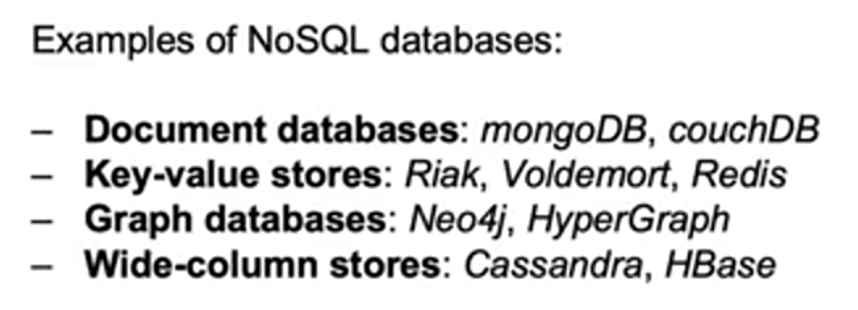

### Reading NoSQL Data

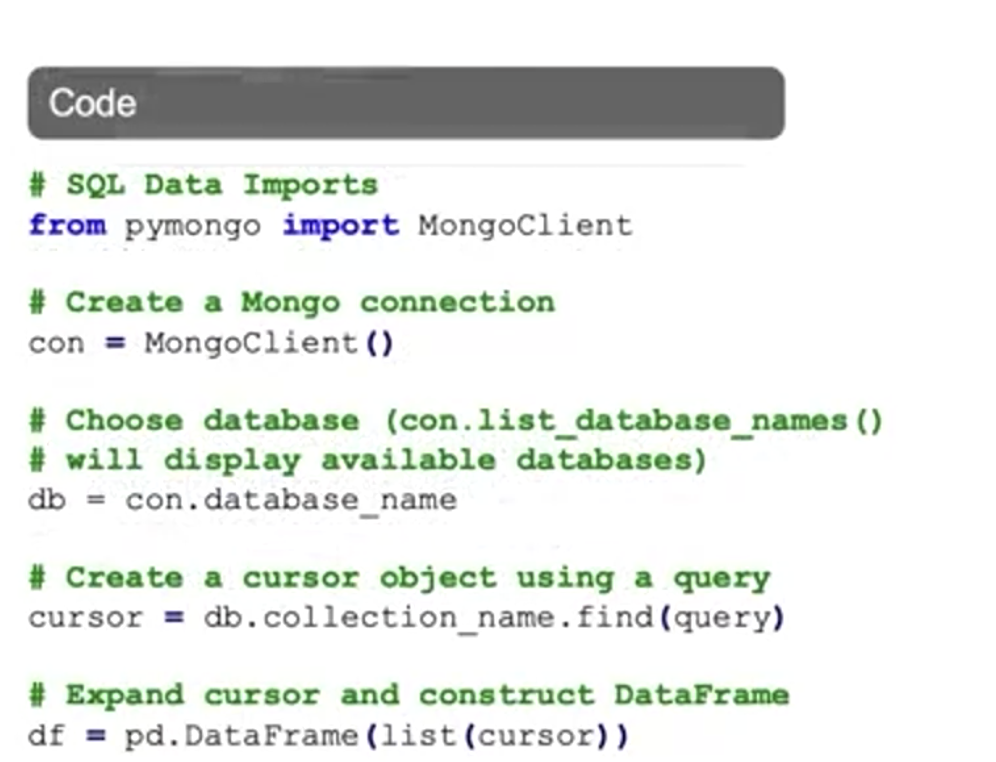

In [18]:
from pymongo import MongoClient
con = MongoClient()
db = con.database_name
cursor = db.collection_name.find({})
df = pd.DataFrame(list(cursor))
print(df.head())

Empty DataFrame
Columns: []
Index: []


---

### Function

**SELECT <cột_hoặc_hàm_tính_toán> AS <tên_mới>** 

**COUNT(*) count all of the item in the columns**

**FROM <tên_bảng>;**

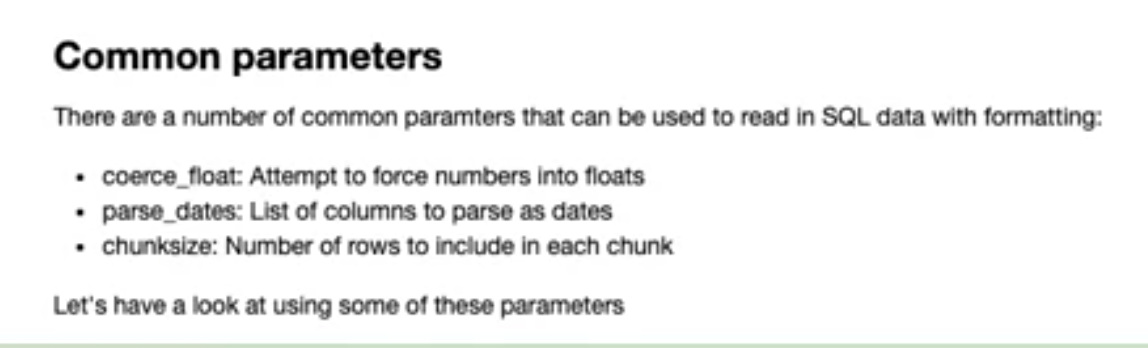

coerce_float: Cố gắng ép kiểu các cột dạng số sang số thực (float). Tham số này hữu ích khi SQL trả về kiểu dữ liệu số thập phân mà Pandas có thể nhận diện nhầm thành chuỗi (object).

parse_dates = "Name" : converts all the data in that column into dates type 

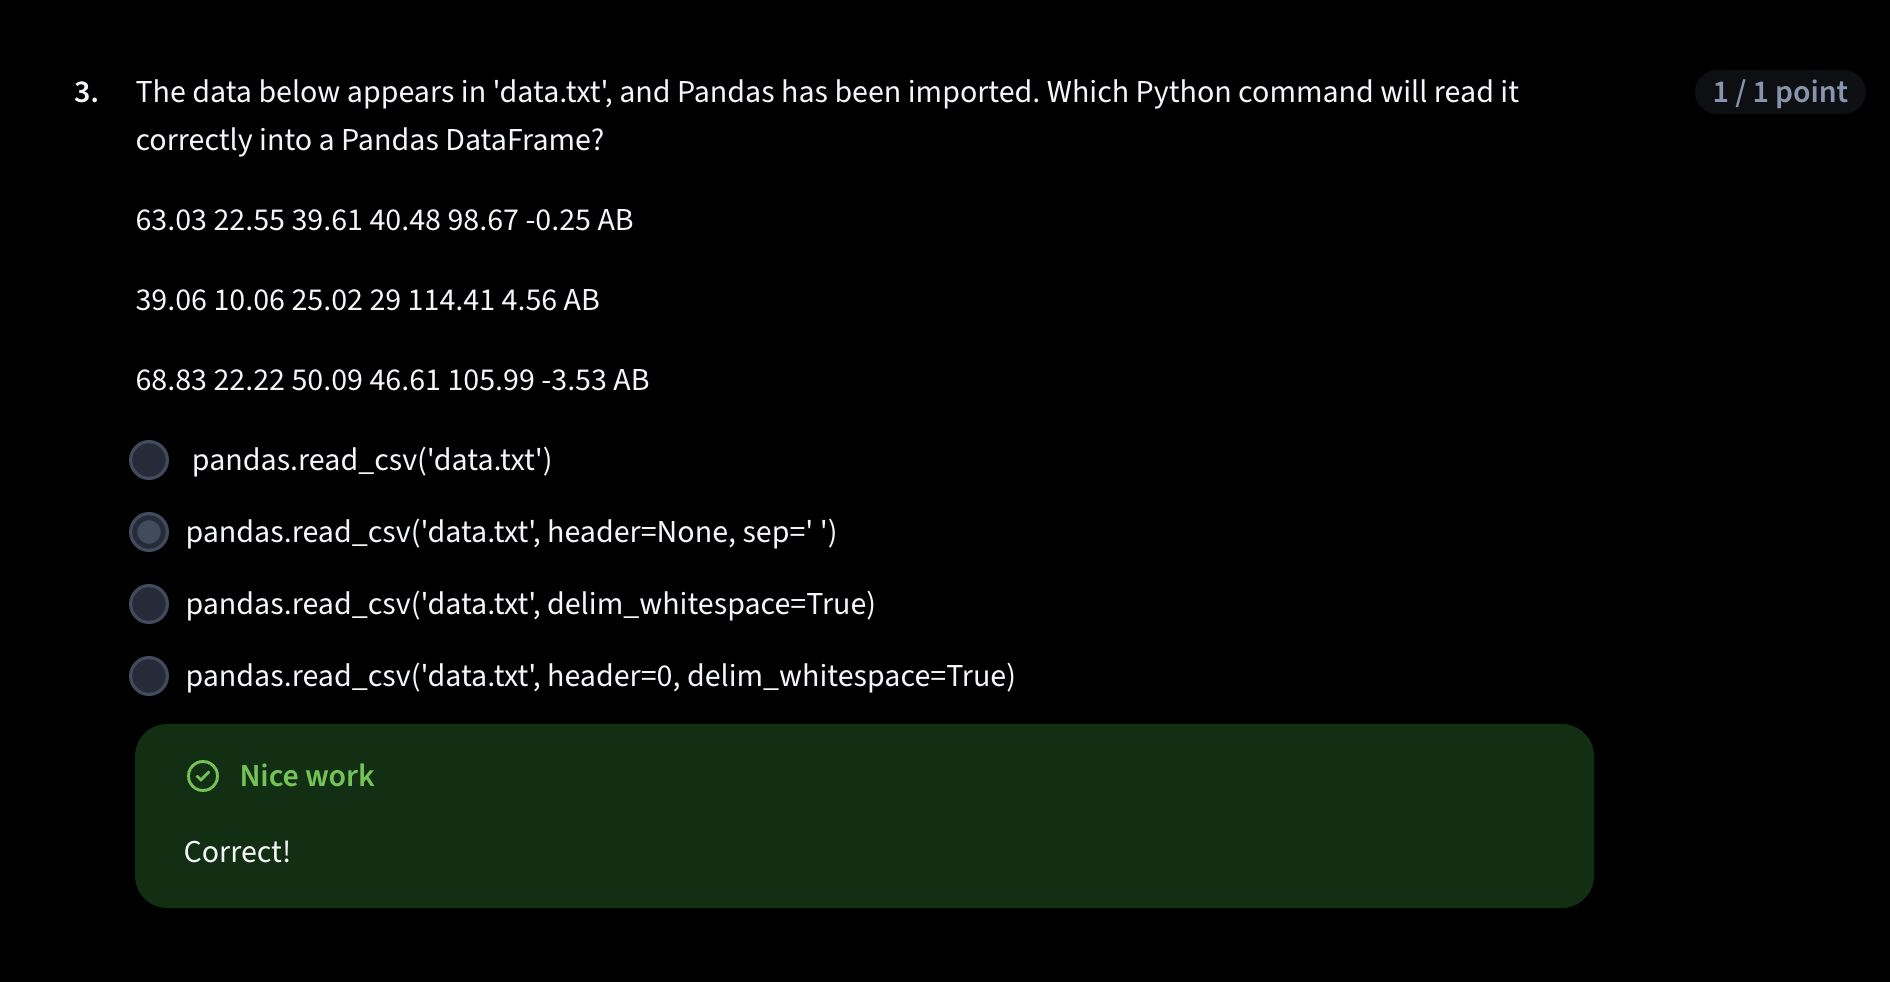

At first, we can noitice that the database have no blank heaader, so we need the syntax header = None to tell the pandas that there is no blank row in the dataaset

Second, `sep = ' '` is True because the gap between our data is separate with only a space

---


## CLEANING DATA (IMPORTANT)

### WHY WE NEED TO CLEAN DATA


- Issues that arise with messy data

- Identify duplicate or unnecesary data

- Policies for dealing with the outlier -- how we copse with the outlier

### KEY ASPECTS OF MACHINE LEARNING WORKFLOW DEPEND ON CLEANED DATA: 

- OBSERVATIONS : An instance of the data (usually a point or row in dataset)

- LABLES : Output variables being predicted -- make sure all labled appropriately 

- ALGORITHMS : Computer programs that estimate models based on available data

- FEATURES : Information we have for each observations (variables)

- MODELS : Hypothesized realtionship between observations and data

A MESSY DATA WILL LEAD TO "GARBAGE-IN" OR "GARBAGE-OUT" EFFECT, AND UNRELIABLE OUTCOMES


### THE MAIN PROBLEMS DATA WE FACE : 

- THE LACK OF DATA

- TOO MUCH DATA

- BAD DATA 


### HOW DATA CAN BE MESSY ?


- DUPLICATE OR UNNECESSARY DATA

- INCONSISTENT TEXT OR TYPOS (văn bản không nhất quán và lỗi chính tả)

- MISSING DATA

- OUTLIER

- DATA SOURCING ISSUES : 

    - MULTIPLE SYSTEMS

    - DIFFERENT DATABASE TYPES

    - ON PERMISES, IN CLOUD (cố gắng tranh luận - i guess xung đột data --> premises)

- AND MORE...


## DUPLICATE OR UNNECESSARY DATA

Pay attention to duplicate values and research why there are multiple values 

--> It's a good idea to look at the features you're bringing in and **filter** the data as necessary (be careful not to filter too much if you may use features later)

## POLICIES FOR MISSING DATA

- REMOVE THE DATA : remove the row(s) entirely
    - The pros : quickly clean your dataset without having a guess on approriate replacement value
    - The cons : end up losing too much information --> biasing our dataset to some reason that the data was not collected for a particular field
- IMMUTE THE DATA : replace with substituted values. Fill in the missing data with the most common value, the average value,...
    - The pros ; we don't lose any row or columns that may be important to our model
- MASK THE DATA : create a catagory for missing value
    - The pros : we don't lose any information for the model
    - The cons : we again add another level of uncertainly to out model


## OUTLIER 

- Is an observation in data that is distant from most other observations

- These observations are aberrations (sai lech) and do not accurately represent the phenomenon we are trying to explain through the model

- If we do not identify and deal with outliers, they can have a significant impact on the model 

## HOW DO WE FIND THE OUTLIER

- We can use plots --> Histogram and Density Plots, Box Plot (BEST HISTOGRAM + KDE)

`sns.histplot(kem thong so kde = True)`

- Statistics --> Interquartile Range, Standard Deviation